In [ ]:
# MACHINE LEARNING PROJECT
# Credit Card Fraud Detection

#import librarie
#import dataset like credit card transactions
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
df=pd.read_csv("https://raw.githubusercontent.com/ArchanaInsights/Datasets/refs/heads/main/credit_card_transactions.csv")


In [ ]:
df.head()

,Transaction_ID,Card_Type,Merchant_Category,Transaction_Amount,Transaction_DateTime,Location,Region,Cardholder_Age,Cardholder_Gender,Cardholder_Monthly_Income,Cardholder_Average_Spend,Credit_Limit,Device_Type,Day_of_Week,Is_Fraudulent
0,W963UK57,Mastercard,Utility bill,27214.0,2020-01-01 09:43:17,Patna,East,23.0,Female,94632.0,36369.65,100000.0,Unknown,Wednesday,No
1,V606KV56,American Express,Retail,83956.0,2020-01-03 16:26:13,Surat,West,49.0,Male,148118.0,89179.12,150000.0,Desktop,Friday,No
2,R531NU70,Visa,Transportation,193280.0,2020-01-04 03:40:49,Patna,East,NaN,Male,210921.0,106668.60,200000.0,Desktop,Saturday,No
3,T783GF79,RuPay,Online Shopping,167381.0,2020-01-04 14:56:24,Surat,West,52.0,Female,148070.0,173155.52,200000.0,Desktop,Saturday,Yes
4,K256ZN73,RuPay,Retail,81170.0,2020-01-04 17:26:47,Lucknow,North,37.0,Female,174470.0,52713.09,200000.0,Mobile,Saturday,No


In [ ]:
df.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Transaction_ID             5000 non-null   object 
 1   Card_Type                  4983 non-null   object 
 2   Merchant_Category          4978 non-null   object 
 3   Transaction_Amount         4994 non-null   float64
 4   Transaction_DateTime       5000 non-null   object 
 5   Location                   5000 non-null   object 
 6   Region                     5000 non-null   object 
 7   Cardholder_Age             4865 non-null   float64
 8   Cardholder_Gender          4911 non-null   object 
 9   Cardholder_Monthly_Income  4686 non-null   float64
 10  Cardholder_Average_Spend   4792 non-null   float64
 11  Credit_Limit               4991 non-null   float64
 12  Device_Type                4960 non-null   object 
 13  Day_of_Week                5000 non-null   objec

In [ ]:
df.describe()

,Transaction_Amount,Cardholder_Age,Cardholder_Monthly_Income,Cardholder_Average_Spend,Credit_Limit
count,4994.000000,4865.000000,4686.000000,4792.000000,4991.000000
mean,74667.995995,49.106680,137353.817542,63058.343566,124654.377880
std,43089.045623,18.398524,69471.623020,40056.989704,55668.246494
min,25008.000000,18.000000,35005.000000,10282.410000,50000.000000
25%,39742.500000,33.000000,73485.000000,33336.742500,100000.000000
50%,60922.000000,49.000000,131833.000000,49547.945000,100000.000000
75%,98373.500000,65.000000,189054.250000,83732.352500,150000.000000
max,199923.000000,80.000000,299907.000000,199898.290000,200000.000000


In [ ]:
df.isnull().sum()

,0
Transaction_ID,0
Card_Type,17
Merchant_Category,22
Transaction_Amount,6
Transaction_DateTime,0
Location,0
Region,0
Cardholder_Age,135
Cardholder_Gender,89
Cardholder_Monthly_Income,314


In [ ]:
df.duplicated().sum()

np.int64(1)

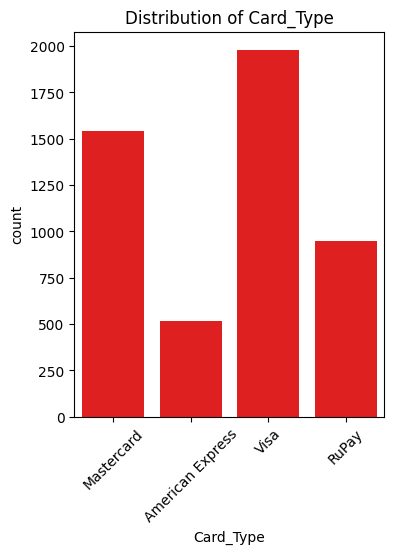

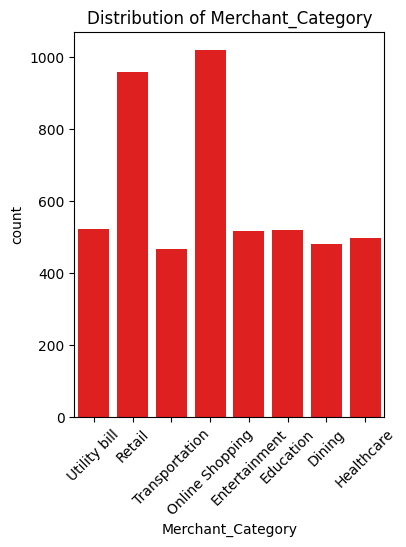

In [ ]:
#EDA(Exploratory data analysis)
#visuvalization
categorical_features = ['Card_Type', 'Merchant_Category']
for feature in categorical_features:

    plt.figure(figsize=(4,5))
    sns.countplot(data=df, x=feature,color='red')
    plt.title(f'Distribution of {feature}')
    plt.xticks(rotation=45)
    plt.show()

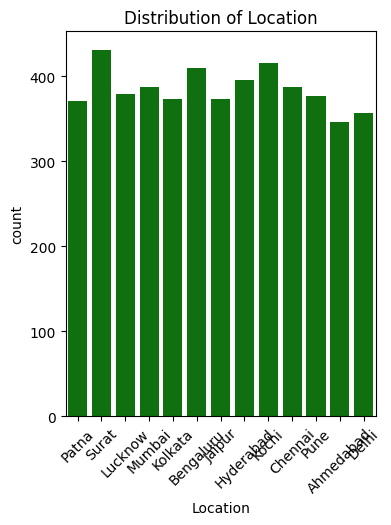

In [ ]:
#Location visualization

categorical_features = ['Location']
for feature in categorical_features:
    plt.figure(figsize=(4,5))
    sns.countplot(data=df, x=feature,color='green')
    plt.title(f'Distribution of {feature}')
    plt.xticks(rotation=45)
    plt.show()


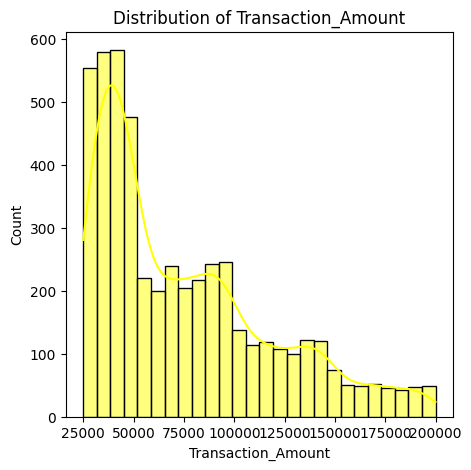

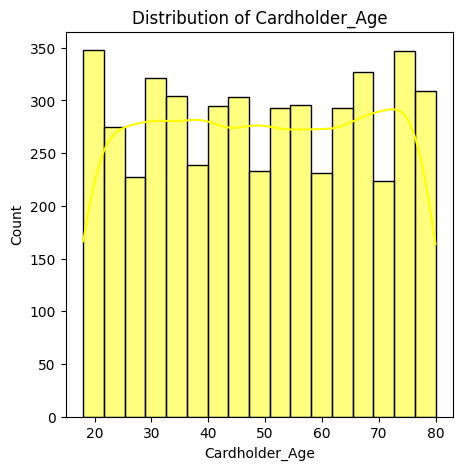

In [ ]:
#
numerical_features = ['Transaction_Amount', 'Cardholder_Age']

for feature in numerical_features:
    plt.figure(figsize=(5, 5))
    sns.histplot(data=df, x=feature, kde=True,color='yellow')
    plt.title(f'Distribution of {feature}')
    plt.show()

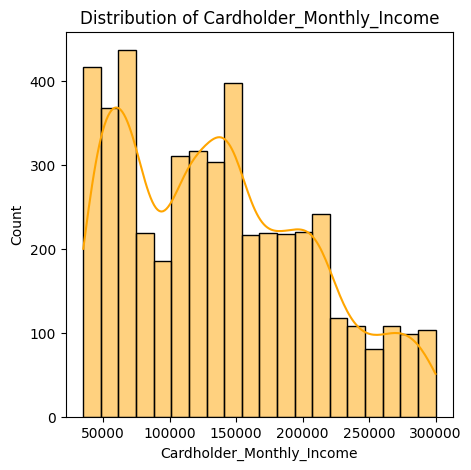

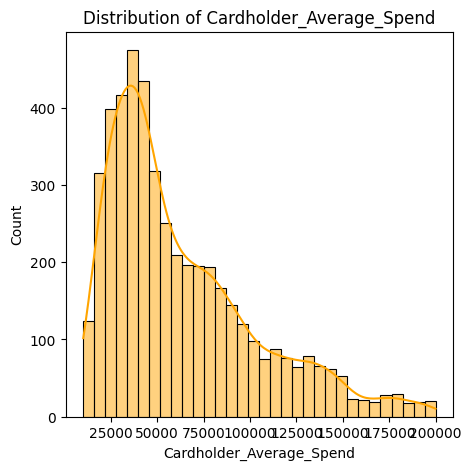

In [ ]:
#
numerical_features = ['Cardholder_Monthly_Income', 'Cardholder_Average_Spend']
for feature in numerical_features:

    plt.figure(figsize=(5, 5))
    sns.histplot(data=df, x=feature, kde=True,color='orange')
    plt.title(f'Distribution of {feature}')
    plt.show()

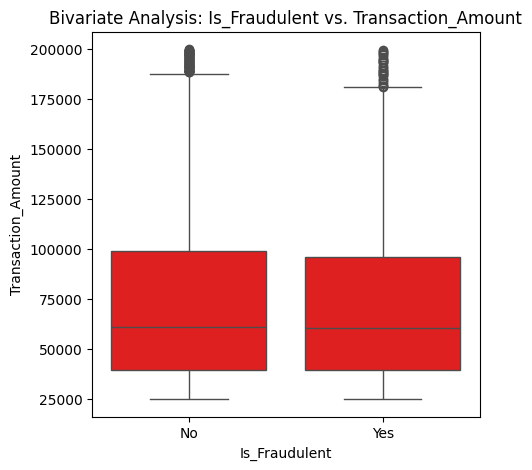

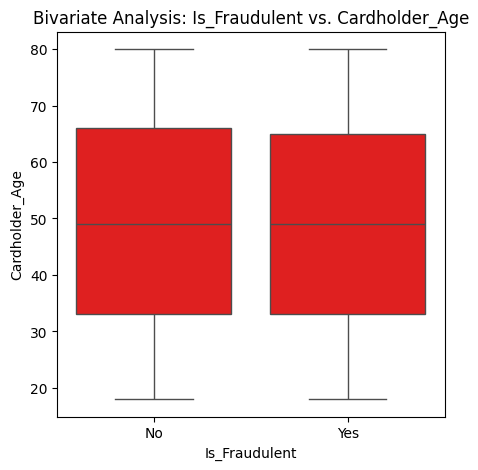

In [ ]:
#
bivariate_features = ['Transaction_Amount', 'Cardholder_Age']
for feature in bivariate_features:

    plt.figure(figsize=(5, 5))
    sns.boxplot(data=df, x='Is_Fraudulent', y=feature,color='red')
    plt.title(f'Bivariate Analysis: Is_Fraudulent vs. {feature}')
    plt.show



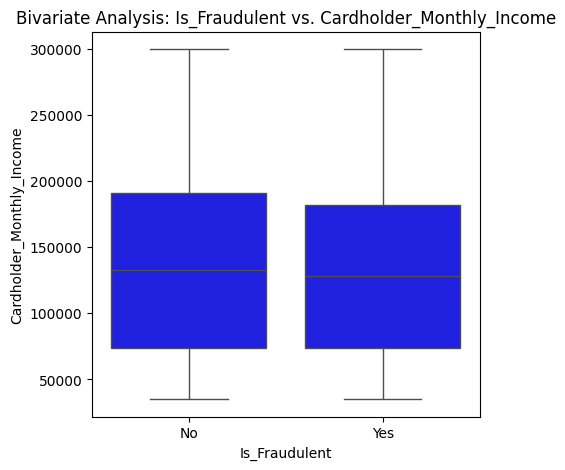

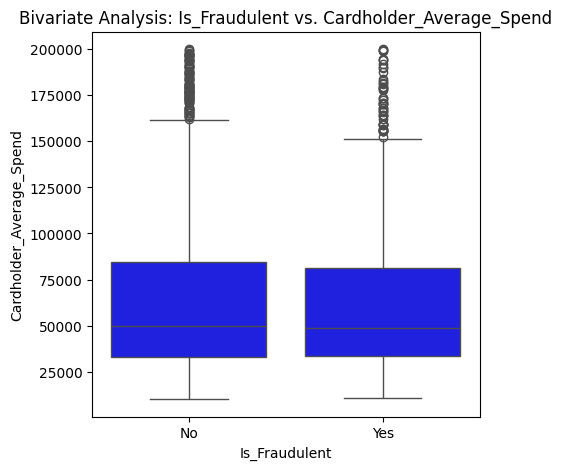

In [ ]:
#'Cardholder_Monthly_Income', 'Cardholder_Average_Spend'
bivariate_features = ['Cardholder_Monthly_Income', 'Cardholder_Average_Spend']
for feature in bivariate_features:

    plt.figure(figsize=(5, 5))
    sns.boxplot(data=df, x='Is_Fraudulent', y=feature,color='blue')
    plt.title(f'Bivariate Analysis: Is_Fraudulent vs. {feature}')
    plt.show



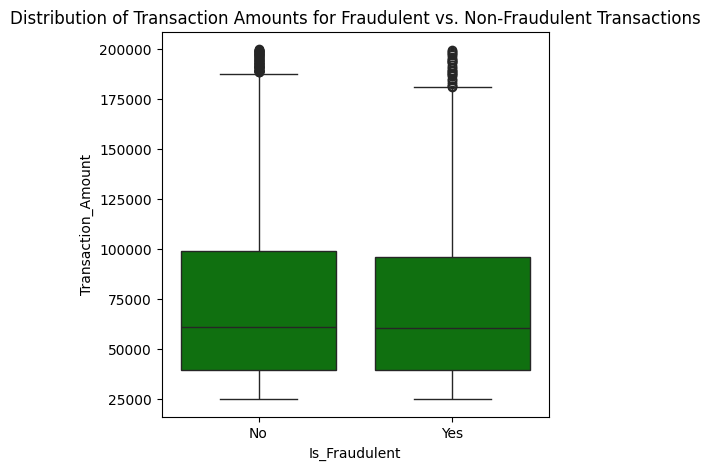

In [ ]:
#d
plt.figure(figsize=(5, 5))
sns.boxplot(data=df, x='Is_Fraudulent', y='Transaction_Amount',color='green')
plt.title('Distribution of Transaction Amounts for Fraudulent vs. Non-Fraudulent Transactions')
plt.show()


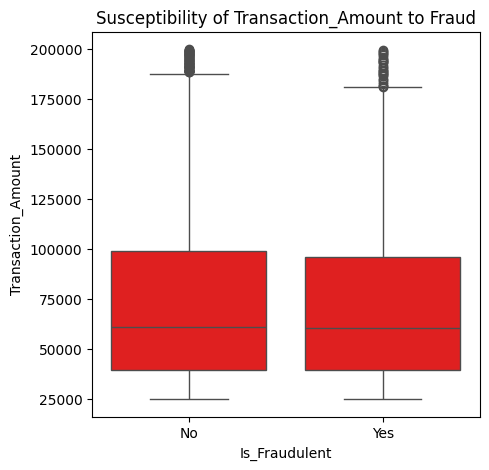

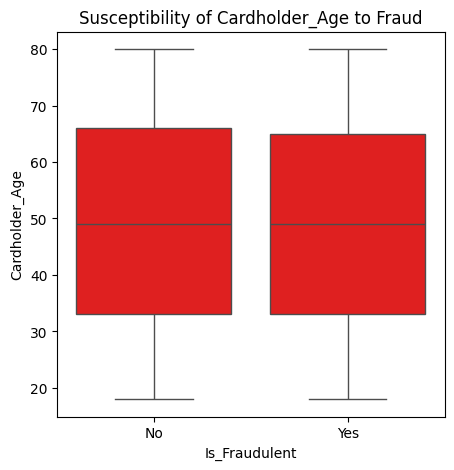

In [ ]:
#
susceptible_features = ['Transaction_Amount', 'Cardholder_Age']
for feature in susceptible_features:
    plt.figure(figsize=(5, 5))
    sns.boxplot(data=df, x='Is_Fraudulent', y=feature,color='red')
    plt.title(f'Susceptibility of {feature} to Fraud')
    plt.show()

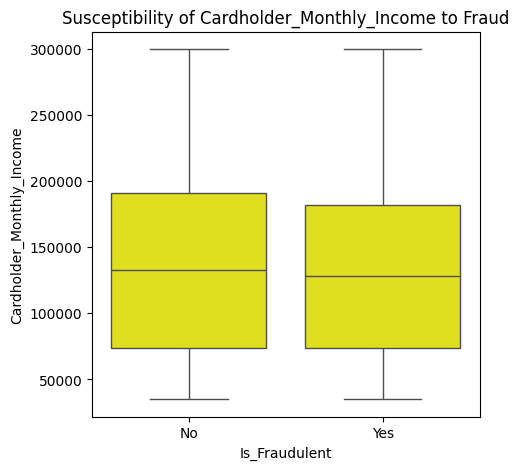

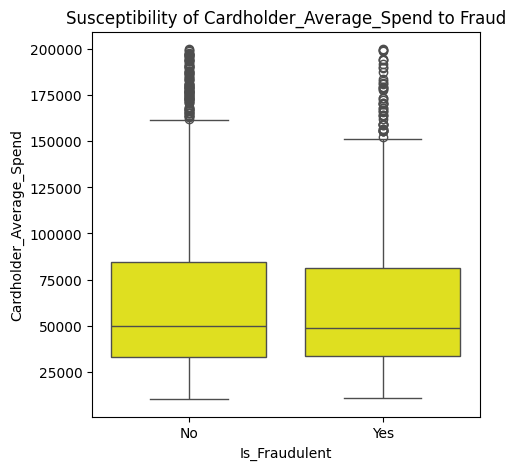

In [ ]:
#
susceptible_features = ['Cardholder_Monthly_Income', 'Cardholder_Average_Spend']
for feature in susceptible_features:

    plt.figure(figsize=(5, 5))
    sns.boxplot(data=df, x='Is_Fraudulent', y=feature,color='yellow')
    plt.title(f'Susceptibility of {feature} to Fraud')
    plt.show()

In [ ]:
#2) Data Preprocessing - Data Cleaning:
##data preprocess method
#import libraries
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
df.isnull().sum()

,0
Transaction_ID,0
Card_Type,17
Merchant_Category,22
Transaction_Amount,6
Transaction_DateTime,0
Location,0
Region,0
Cardholder_Age,135
Cardholder_Gender,89
Cardholder_Monthly_Income,314


In [ ]:
#missing value
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
Transaction_ID,0
Card_Type,0
Merchant_Category,0
Transaction_Amount,0
Transaction_DateTime,0
Location,0
Region,0
Cardholder_Age,0
Cardholder_Gender,0
Cardholder_Monthly_Income,0


In [ ]:
#
numerical_features = ['Transaction_Amount', 'Cardholder_Age', 'Cardholder_Monthly_Income', 'Cardholder_Average_Spend']
for feature in numerical_features:

    Z_scores = np.abs((df[feature] - df[feature].mean()) / df[feature].std())
    df=df[Z_scores < 3]
    print(f"Number of rows after removing outliers for {feature}: ")
    print(df.shape)

Number of rows after removing outliers for Transaction_Amount: 
(4220, 15)
Number of rows after removing outliers for Cardholder_Age: 
(4220, 15)
Number of rows after removing outliers for Cardholder_Monthly_Income: 
(4220, 15)
Number of rows after removing outliers for Cardholder_Average_Spend: 
(4171, 15)


In [ ]:
#
numerical_features = ['Transaction_Amount', 'Cardholder_Age', 'Cardholder_Monthly_Income', 'Cardholder_Average_Spend']
for feature in numerical_features:

    skewness = df[feature].skew()
    print(f"Skewness of {feature}: {skewness}")

Skewness of Transaction_Amount: 0.9940806690386854
Skewness of Cardholder_Age: -0.0012444486939281207
Skewness of Cardholder_Monthly_Income: 0.4437870625271218
Skewness of Cardholder_Average_Spend: 1.0590277903967404


In [ ]:
#feature scaling:
#
categorical_features = ['Card_Type', 'Merchant_Category', 'Location']
for feature in categorical_features:
    print(f"Unique values in {feature}: ")
    print(df[feature].unique())
    print('\n')

Unique values in Card_Type: 
['Mastercard' 'American Express' 'RuPay' 'Visa']


Unique values in Merchant_Category: 
['Utility bill' 'Retail' 'Online Shopping' 'Entertainment' 'Education'
 'Dining' 'Transportation' 'Healthcare']


Unique values in Location: 
['Patna' 'Surat' 'Lucknow' 'Mumbai' 'Kolkata' 'Bengaluru' 'Jaipur'
 'Hyderabad' 'Kochi' 'Chennai' 'Pune' 'Delhi' 'Ahmedabad']




In [ ]:
#

from sklearn.preprocessing import LabelEncoder,OneHotEncoder
label_encoder = LabelEncoder()
df['Cardholder_Gender'] = label_encoder.fit_transform(df['Cardholder_Gender'])
df['Day_of_Week'] = label_encoder.fit_transform(df['Day_of_Week'])
print(df.head())

  Transaction_ID         Card_Type Merchant_Category  Transaction_Amount  \
0       W963UK57        Mastercard      Utility bill             27214.0   
1       V606KV56  American Express            Retail             83956.0   
3       T783GF79             RuPay   Online Shopping            167381.0   
4       K256ZN73             RuPay            Retail             81170.0   
5       I812SG19             RuPay     Entertainment            131918.0   

  Transaction_DateTime Location Region  Cardholder_Age  Cardholder_Gender  \
0  2020-01-01 09:43:17    Patna   East            23.0                  0   
1  2020-01-03 16:26:13    Surat   West            49.0                  1   
3  2020-01-04 14:56:24    Surat   West            52.0                  0   
4  2020-01-04 17:26:47  Lucknow  North            37.0                  0   
5  2020-01-04 19:55:12   Mumbai   West            80.0                  1   

   Cardholder_Monthly_Income  Cardholder_Average_Spend  Credit_Limit  \
0       

In [ ]:
#feature selection
#a)
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer  # Import SimpleImputer for imputation
label_encoder = {}
categorical_cols = ['Card_Type','Merchant_Category','Location','Region','Device_Type','Cardholder_Gender','Day_of_Week']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoder[col] = le

x = df.drop(columns=['Transaction_ID','Transaction_DateTime','Is_Fraudulent'])
y = df['Is_Fraudulent']

# Impute missing values with the most frequent value for each column
imputer = SimpleImputer(strategy='most_frequent') # Create an imputer instance
x_imputed = imputer.fit_transform(x) # Impute missing values in x

k_best = SelectKBest(score_func = f_classif,k=5)
x_selected = k_best.fit_transform(x_imputed,y) # Use the imputed data
selected_feature = x.columns[k_best.get_support()]
print("Top selected features:",selected_feature)

Top selected features: Index(['Merchant_Category', 'Region', 'Cardholder_Monthly_Income',
       'Credit_Limit', 'Device_Type'],
      dtype='object')


In [ ]:
#b)
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import LabelEncoder
feature_scores = pd.DataFrame({'Feature': x.columns, 'Score': k_best.scores_})
feature_scores = feature_scores.sort_values(by='Score', ascending=False)
print(feature_scores)

                      Feature     Score
4                      Region  8.381462
7   Cardholder_Monthly_Income  1.534575
10                Device_Type  1.286540
9                Credit_Limit  1.265309
1           Merchant_Category  1.189622
2          Transaction_Amount  1.152547
8    Cardholder_Average_Spend  0.978580
11                Day_of_Week  0.841564
5              Cardholder_Age  0.571473
3                    Location  0.477875
6           Cardholder_Gender  0.400286
0                   Card_Type  0.151067


In [ ]:
#spliting data process:
#a)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# b) Ensure that both sets maintain the same distribution of fraudulent and non-fraudulent transactions to avoid data leakage.
print(df['Is_Fraudulent'].value_counts(normalize=True)*100)
x = df.drop(columns=['Transaction_ID','Transaction_DateTime','Is_Fraudulent'])# define the target
y = df['Is_Fraudulent']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42 , stratify=y)
print(y_train.value_counts(normalize=True)*100)
print(y_test.value_counts(normalize=True)*100)


Is_Fraudulent
No     73.531527
Yes    26.468473
Name: proportion, dtype: float64
Is_Fraudulent
No     73.531175
Yes    26.468825
Name: proportion, dtype: float64
Is_Fraudulent
No     73.532934
Yes    26.467066
Name: proportion, dtype: float64


In [ ]:
#feature scaling
# a) Scale numerical features to ensure :
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#b)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#building and machine learning model:
# a) Import the necessary modules and libraries for building and evaluating machine learning models.
from sklearn.linear_model import LogisticRegression # Logistic Regression Model
from sklearn.ensemble import RandomForestClassifier # Random Forest Model
from sklearn.svm import SVC # SVC Model
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier # Decision Tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer

In [ ]:
#
 #b) Define a list or dictionary of classifiers to be evaluated;
classifiers = {
    'Logistic Regression': LogisticRegression(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'SVM': SVC()
}
# Create an imputer instance to fill NaN values with the mean
imputer = SimpleImputer(strategy='mean')

results = [] # Initialize an empty list to store results

for name, clf in classifiers.items():
    # Fit the imputer on the training data :
    X_train_imputed = imputer.fit_transform(X_train_scaled)
    X_test_imputed = imputer.transform(X_test_scaled)

    clf.fit(X_train_imputed, y_train)
    y_pred = clf.predict(X_test_imputed)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred , pos_label='Yes')
    print(f"{name} - Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}")

Logistic Regression - Accuracy: 0.7353, F1-Score: 0.0000
Naive Bayes - Accuracy: 0.7353, F1-Score: 0.0000
Decision Tree - Accuracy: 0.5976, F1-Score: 0.3029
Random Forest - Accuracy: 0.7377, F1-Score: 0.0437
K-Nearest Neighbors - Accuracy: 0.6826, F1-Score: 0.1587
SVM - Accuracy: 0.7353, F1-Score: 0.0000


In [ ]:
#c
# c) Select a machine learning algorithm :
results_df = pd.DataFrame(results, columns=['Classifier', 'Accuracy', 'F1_score'])

best_model = results_df.sort_values(by="F1_score",ascending = False).head(1)
print("Best model F1 score")
print(best_model)

Best model F1 score
Empty DataFrame
Columns: [Classifier, Accuracy, F1_score]
Index: []


In [ ]:
#
# D) Train the selected model using the training dataset:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
best_model = LogisticRegression()
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train_scaled)
X_test_imputed = imputer.transform(X_test_scaled)
best_model.fit(X_train_imputed, y_train)
y_pred = best_model.predict(X_test_imputed)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred , pos_label='Yes')
print(f"Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}")


Accuracy: 0.7353, F1-Score: 0.0000


In [ ]:
#e)Validate the model's performance on the testing dataset and interpret the results to assess
#its effectiveness in detecting fraudulent transactions.

conf_matrix = confusion_matrix(y_test,y_pred)
accuracy = accuracy_score(y_test,y_pred)

precision = precision_score(y_test,y_pred, pos_label='Yes')
recall = recall_score(y_test,y_pred, pos_label='Yes')
f1 = f1_score(y_test,y_pred, pos_label='Yes')

print("\n Model Evaluation Matrix:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1_score: {f1:.2f}")

print("\nConfusion Matrix:")
print(conf_matrix)


 Model Evaluation Matrix:
Accuracy: 0.74
Precision: 0.00
Recall: 0.00
F1_score: 0.00

Confusion Matrix:
[[614   0]
 [221   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
